**Dataset Info** :
I am analyzing a student placement dataset to identify factors that influence whether a student gets placed and their salary package. This analysis can help students improve their skills and increase placement chances.

The dataset contains 100,000 rows and 26 columns and was sourced from Kaggle. It includes features like CGPA, internships, coding skills, communication skills, and placement status.

## Importing Required Libraries

In this step, we import the necessary Python libraries for data analysis and visualization.

- **Pandas** is used for handling and analyzing structured data.
- **NumPy** is used for numerical operations.
- **Matplotlib** is used for creating basic visualizations.
- **Seaborn** is used for advanced data visualization and statistical plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading and Understanding the Dataset

In this step, we load the dataset and examine its structure. We display the first few rows, check the number of rows and columns, and identify the data types of each column.

In [4]:
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

# Display first 5 rows
df.head(5)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [5]:
# Check shape of dataset
df.shape

(100000, 26)

In [6]:
# Check data types
df.dtypes

,0
student_id,int64
age,int64
gender,object
cgpa,float64
branch,object
college_tier,object
internships_count,int64
projects_count,int64
certifications_count,int64
coding_skill_score,float64


The dataset contains 100,000 rows and 26 columns. It includes both numerical and categorical variables such as CGPA, salary package, and placement status.

## Data Cleaning

Data cleaning is an important step to ensure the dataset is accurate and usable. In this step, we check for missing values and duplicate records and handle them appropriately.

In [7]:
# Check missing values
df.isnull().sum()

,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


From the above output, we can observe whether there are missing values in the dataset. If missing values exist, they need to be handled.

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Missing values in numerical columns were filled using the mean value. This approach helps retain all rows while maintaining data consistency.

In [9]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# Remove duplicates
df.drop_duplicates(inplace=True)

Duplicate rows were removed to avoid bias and ensure accurate analysis.

## Statistical Analysis

In this step, we calculate statistical measures such as mean, median, mode, standard deviation, variance, range, and mid-range for selected numerical columns.

In [11]:
# CGPA Statistics
df['cgpa'].mean()
df['cgpa'].median()
df['cgpa'].mode()
df['cgpa'].std()
df['cgpa'].var()

# Range
df['cgpa'].max() - df['cgpa'].min()

# Mid-range
(df['cgpa'].max() + df['cgpa'].min()) / 2

7.25

In [12]:
# Salary Statistics
df['salary_package_lpa'].mean()
df['salary_package_lpa'].median()
df['salary_package_lpa'].mode()
df['salary_package_lpa'].std()
df['salary_package_lpa'].var()

# Range
df['salary_package_lpa'].max() - df['salary_package_lpa'].min()

# Mid-range
(df['salary_package_lpa'].max() + df['salary_package_lpa'].min()) / 2

10.22

The statistical analysis shows the central tendency and spread of CGPA and salary. The mean and median indicate average performance, while standard deviation and variance show how much the values vary.

## Data Visualization

Visualization helps in understanding patterns and relationships in the data. In this section, we create different types of charts.

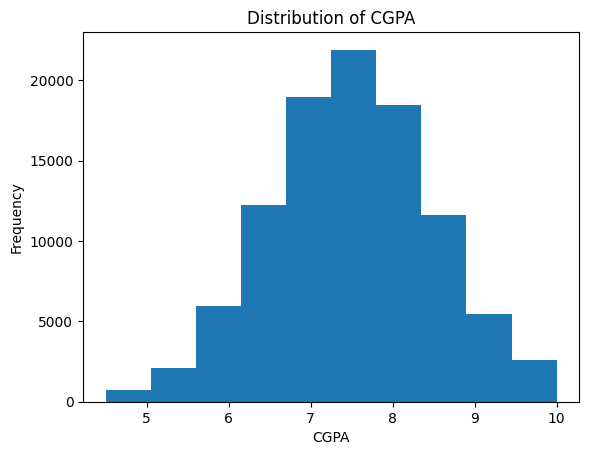

In [13]:
plt.hist(df['cgpa'])
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of CGPA. Most students have CGPA values concentrated in a specific range, indicating common academic performance levels.

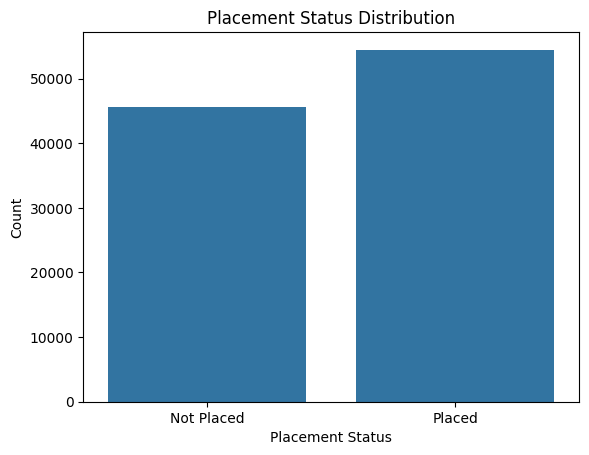

In [14]:
sns.countplot(x='placement_status', data=df)
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

The countplot shows the number of students who are placed and not placed. It helps in understanding placement trends.

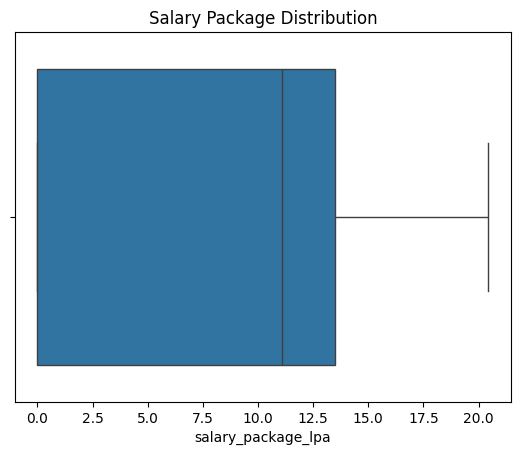

In [15]:
sns.boxplot(x=df['salary_package_lpa'])
plt.title("Salary Package Distribution")
plt.show()

The boxplot shows the spread of salary packages and highlights the presence of outliers. Some students receive significantly higher packages than others.

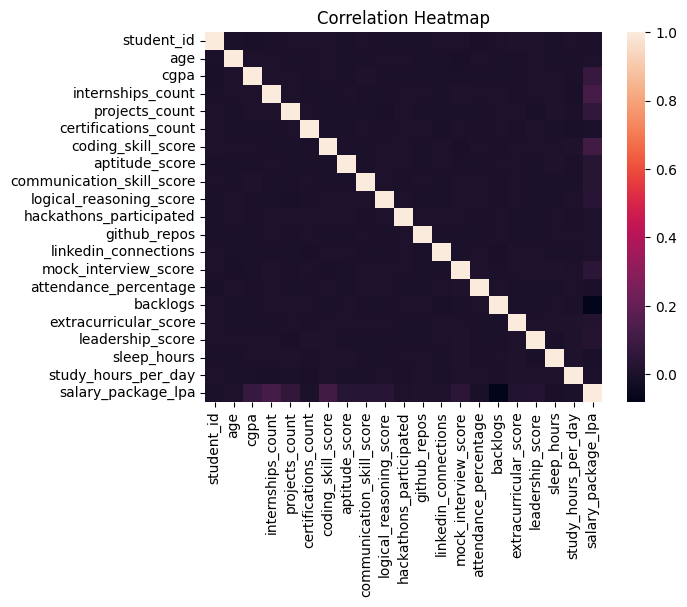

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between numerical variables. Strong correlations indicate important factors influencing placement and salary.

## Predictive Analysis

In this step, we build a simple machine learning model to predict whether a student will be placed based on various features.

In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('placement_status_Placed', axis=1)
y = df_encoded['placement_status_Placed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

The model predicts whether a student will be placed or not. The accuracy score indicates how well the model performs. A higher accuracy means the model is better at predicting placement outcomes.

## Insights

1. Students with higher CGPA tend to have better placement outcomes.
2. Salary distribution shows that a few students receive very high packages, indicating outliers.
3. Correlation analysis suggests that skills such as coding and internships positively impact placement chances.

## Recommendations

1. Students should focus on improving their CGPA and technical skills to increase placement chances.
2. Colleges should provide more internship opportunities and skill-based training programs.